In [180]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# K-MEANS CLUSTER

In [181]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [182]:
df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [183]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [184]:
inertia = []
k_range = range(1,11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia
# here we can cleary see that k=3 is the best value as at 3 the elbow bend starts

[1000.0000000000002,
 297.8954141051722,
 11.575484723104978,
 9.752067977356838,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595288,
 5.70417717790143,
 5.0602341335320755,
 4.762361898130396]

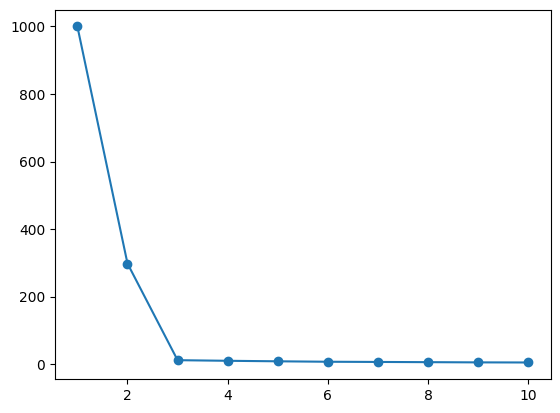

In [185]:
plt.plot(k_range,inertia,marker="o")

In [186]:
kmeans_final = KMeans(n_clusters=3,random_state=42)

# now we want the clusted labels and turn it into a column
cluster_labels = kmeans_final.fit_predict(X_scaled)
df["clusters"] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

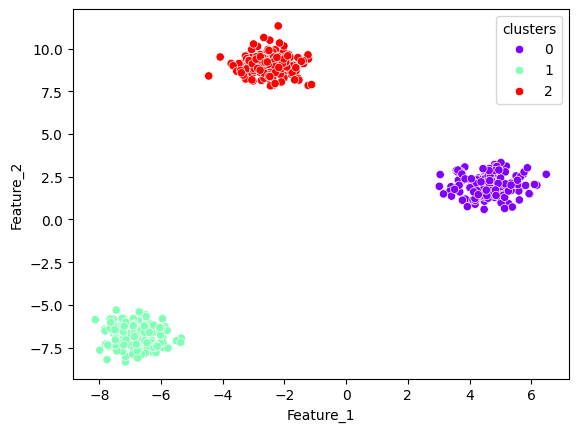

In [187]:
# now we will create a scatter plot to visually see the different clusters
sns.scatterplot(x=df["Feature_1"], y=df["Feature_2"], hue=df["clusters"], palette="rainbow")

# DB SCAN

In [188]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons

In [189]:
# noise is that length or circle
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

scaler = StandardScaler()

df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])

X_scaled = scaler.fit_transform(df)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

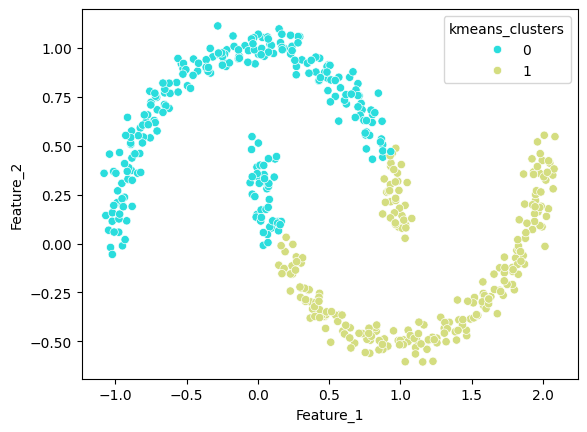

In [190]:
# we will make both kmeans and dbscan here

kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df["kmeans_clusters"] = kmeans_labels

sns.scatterplot(x=df["Feature_1"], y=df["Feature_2"], hue=df["kmeans_clusters"], palette="rainbow")

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

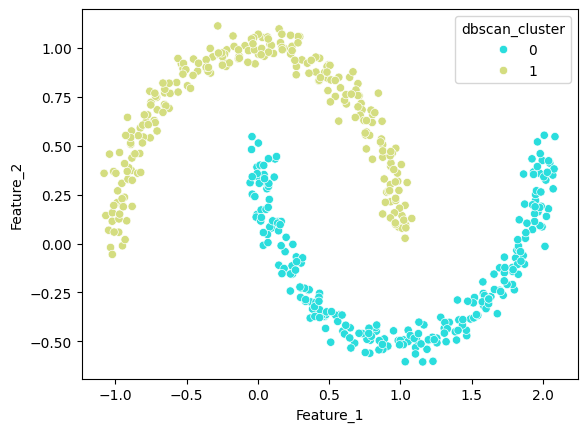

In [191]:
# lets use DB scan
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["dbscan_cluster"] = dbscan_labels

sns.scatterplot(x=df["Feature_1"], y=df["Feature_2"], hue=df["dbscan_cluster"], palette="rainbow")